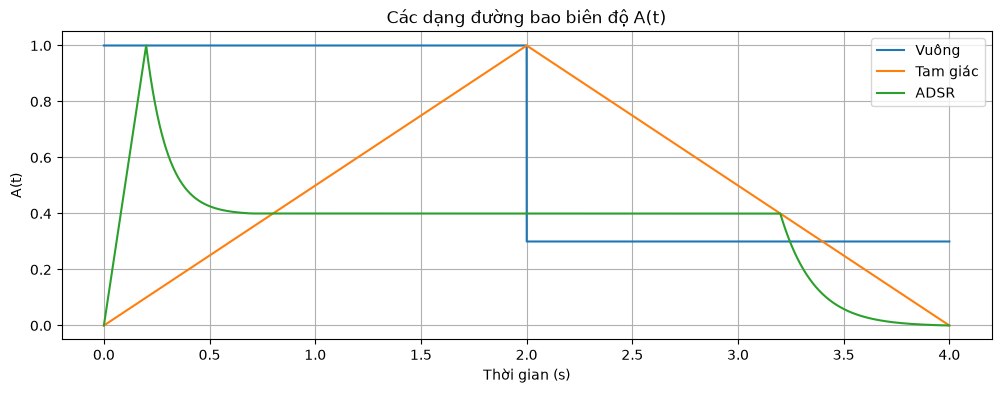

Đang phát đường bao VUÔNG...
Đang phát đường bao TAM GIÁC...
Đang phát đường bao ADSR...


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd


# ==================================================
# 1. THÔNG SỐ
# ==================================================

fs = 44100
f0 = 440
duration = 4

t = np.arange(0, duration, 1/fs)


# ==================================================
# 2. TẠO ĐƯỜNG BAO DẠNG VUÔNG
# ==================================================

A_square = np.zeros(len(t))

A_square[t < duration / 2] = 1
A_square[t >= duration / 2] = 0.3


# ==================================================
# 3. TẠO ĐƯỜNG BAO DẠNG TAM GIÁC
# ==================================================

A_triangle = np.zeros(len(t))

N = len(t)

# Nửa đầu: 0 → 1
A_triangle[:N//2] = np.linspace(0, 1, N//2)

# Nửa sau: 1 → 0
A_triangle[N//2:] = np.linspace(1, 0, N - N//2)


# ==================================================
# 4. TẠO ĐƯỜNG BAO ADSR
# ==================================================

A_adsr = np.zeros(len(t))


# ---------- ATTACK ----------
T_attack = 0.2
N_attack = int(T_attack * fs)

A_adsr[:N_attack] = np.linspace(0, 1, N_attack)


# ---------- DECAY ----------
T_decay = 0.5
N_decay = int(T_decay * fs)

start_decay = N_attack
end_decay = start_decay + N_decay

u = np.linspace(0, 1, N_decay)

A_adsr[start_decay:end_decay] = (
    0.4
    + 0.6 *
    (np.exp(-5 * u) - np.exp(-5))
    / (1 - np.exp(-5))
)


# ---------- SUSTAIN ----------
A_adsr[end_decay:] = 0.4


# ---------- RELEASE ----------
T_release = 0.8
N_release = int(T_release * fs)

start_release = len(t) - N_release

u = np.linspace(0, 1, N_release)

A_adsr[start_release:] = (
    0.4 *
    (np.exp(-5 * u) - np.exp(-5))
    / (1 - np.exp(-5))
)


# ==================================================
# 5. VẼ 3 DẠNG A(t)
# ==================================================

plt.figure(figsize=(12, 4))

plt.plot(t, A_square, label="Vuông")
plt.plot(t, A_triangle, label="Tam giác")
plt.plot(t, A_adsr, label="ADSR")

plt.xlabel("Thời gian (s)")
plt.ylabel("A(t)")
plt.title("Các dạng đường bao biên độ A(t)")

plt.legend()
plt.grid()
plt.show()


# ==================================================
# 6. TẠO SÓNG ÂM
# ==================================================

sine_wave = np.sin(2 * np.pi * f0 * t)


# ==================================================
# 7. ÁP DỤNG TỪNG ĐƯỜNG BAO
# ==================================================

sound_square = A_square * sine_wave

sound_triangle = A_triangle * sine_wave

sound_adsr = A_adsr * sine_wave


# ==================================================
# 8. NGHE THỬ
# ==================================================

print("Đang phát đường bao VUÔNG...")
sd.play(sound_square, fs)
sd.wait()

print("Đang phát đường bao TAM GIÁC...")
sd.play(sound_triangle, fs)
sd.wait()

print("Đang phát đường bao ADSR...")
sd.play(sound_adsr, fs)
sd.wait()